In [ ]:
df.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Max_Stage', 'BIA-BIA_Activity_Level_num',
       'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'FGC_Flexibility_Avg',
       'FGC_Grip_Avg', 'PAQ_Total', 'SDS_measured', 'BIA_measured',
       'FGC_Muscular_Endurance', 'Social_Digital_Displacement',
       'Lifestyle_Risk_Score', 'Metabolic_Alarms_Count',
       'ScreenTime_Age_Ratio', 'ScreenTime_Category'],
      dtype='object')

#GRIDSEARCH

MIGLIORI PARAMETRI TROVATI: 'alpha': 0.001, 'batch_size': 64, 'hidden_layer_sizes': (512, 128), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001

Inizio Grid Search (può richiedere tempo)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

MIGLIORI PARAMETRI TROVATI:
{'alpha': 0.001, 'batch_size': 64, 'hidden_layer_sizes': (512, 128), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001}

Report Classificazione (Test Set):
              precision    recall  f1-score   support

           0       0.73      0.72      0.72      1162
           1       0.21      0.24      0.23       316
           2       0.19      0.18      0.18       189
           3       0.05      0.06      0.05        17

    accuracy                           0.56      1684
   macro avg       0.30      0.30      0.30      1684
weighted avg       0.57      0.56      0.56      1684



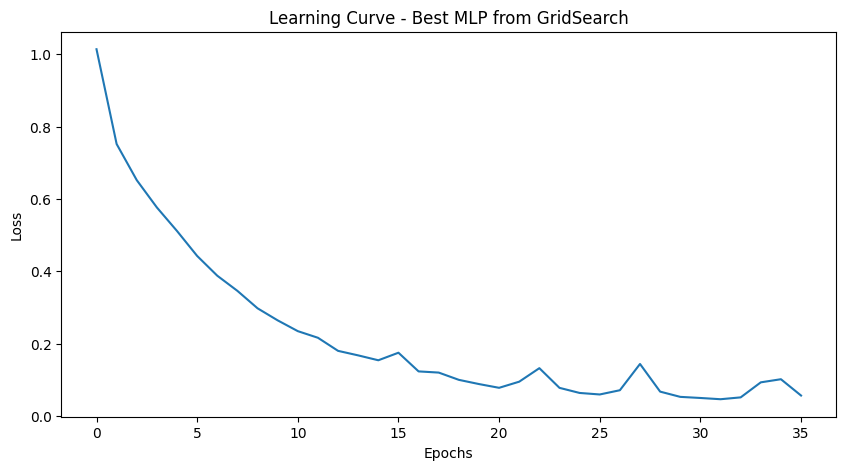

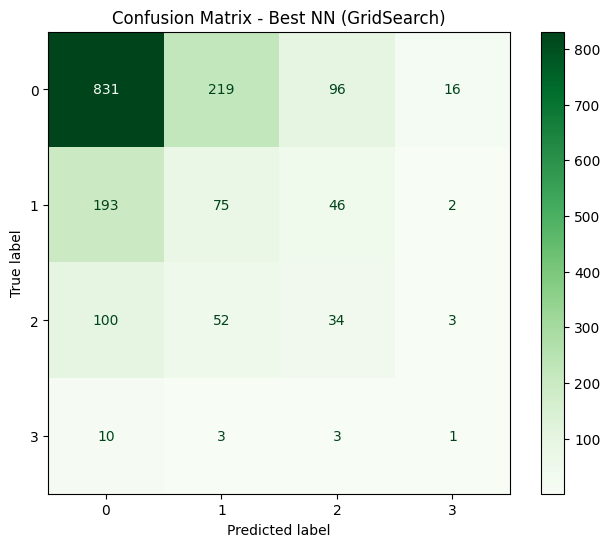

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.utils import resample

# 1. CARICAMENTO E PREPROCESSING
df = pd.read_csv('cmi_module1_clean-1.csv')
X = df.drop(columns=['sii', 'BIA_measured', 'SDS_measured', 'Basic_Demos-Sex,', 'ScreenTime_Category', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_Frame_num'], errors='ignore')
y = df['sii'].astype(int)

# Imputazione e Encoding
#X = X.fillna(X.median())
#cols_to_encode = ['BIA-BIA_Activity_Level_num', 'BIA-BIA_Frame_num']
#X = pd.get_dummies(X, columns=cols_to_encode, drop_first=True)

# 2. SPLIT TRAIN/TEST (20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. BILANCIAMENTO MANUALE (Oversampling sul solo Training Set)
train_combined = pd.concat([X_train, y_train], axis=1)
df_balanced = pd.DataFrame()
for label in [0, 1, 2, 3]:
    class_df = train_combined[train_combined.sii == label]
    resampled = resample(class_df, replace=True, n_samples=len(train_combined[train_combined.sii == 0]), random_state=42)
    df_balanced = pd.concat([df_balanced, resampled])

X_train_res = df_balanced.drop('sii', axis=1)
y_train_res = df_balanced['sii']

# 4. SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# 5. GRID SEARCH CON PARAMETRI "TIPS & TRICKS"
# Definiamo i range ispirati dai tuoi file e dai consigli
param_grid = {
    'hidden_layer_sizes': [(256, 128, 64), (512, 128)],
    'learning_rate_init': [0.0003, 0.001],
    'alpha': [0.001, 0.05],
    'batch_size': [64, 128],
    'learning_rate': ['adaptive']
}

# Usiamo StratifiedKFold per la Cross-Validation
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

mlp = MLPClassifier(
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Inizio Grid Search (può richiedere tempo)...")
grid_search.fit(X_train_scaled, y_train_res)

# 6. RISULTATI FINALI
best_mlp = grid_search.best_estimator_
y_pred = best_mlp.predict(X_test_scaled)

print("\n" + "="*40)
print(f"MIGLIORI PARAMETRI TROVATI:\n{grid_search.best_params_}")
print("="*40)

# 7. VISUALIZZAZIONE CURVA DI APPRENDIMENTO DEL MIGLIOR MODELLO
plt.figure(figsize=(10, 5))
plt.plot(best_mlp.loss_curve_)
plt.title("Learning Curve - Best MLP from GridSearch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.savefig('best_nn_loss_curve.png')

# 8. MATRICE DI CONFUSIONE E REPORT
print("\nReport Classificazione (Test Set):")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Greens', ax=ax)
plt.title("Confusion Matrix - Best NN (GridSearch)")
plt.savefig('best_nn_confusion_matrix.png')

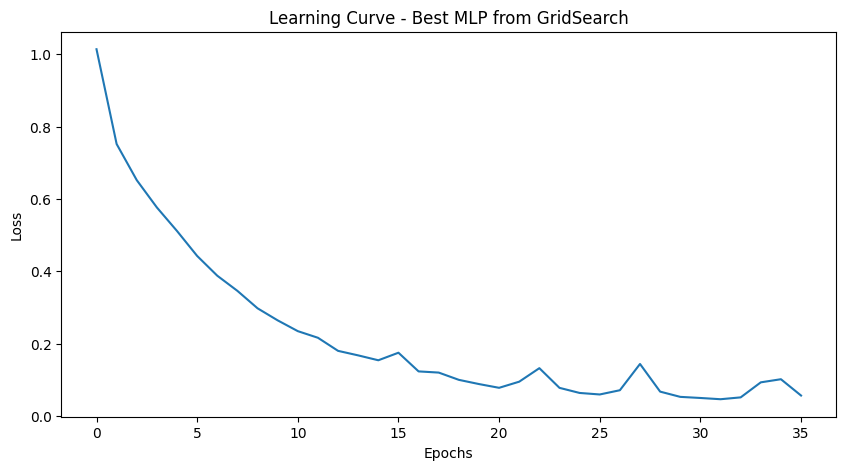

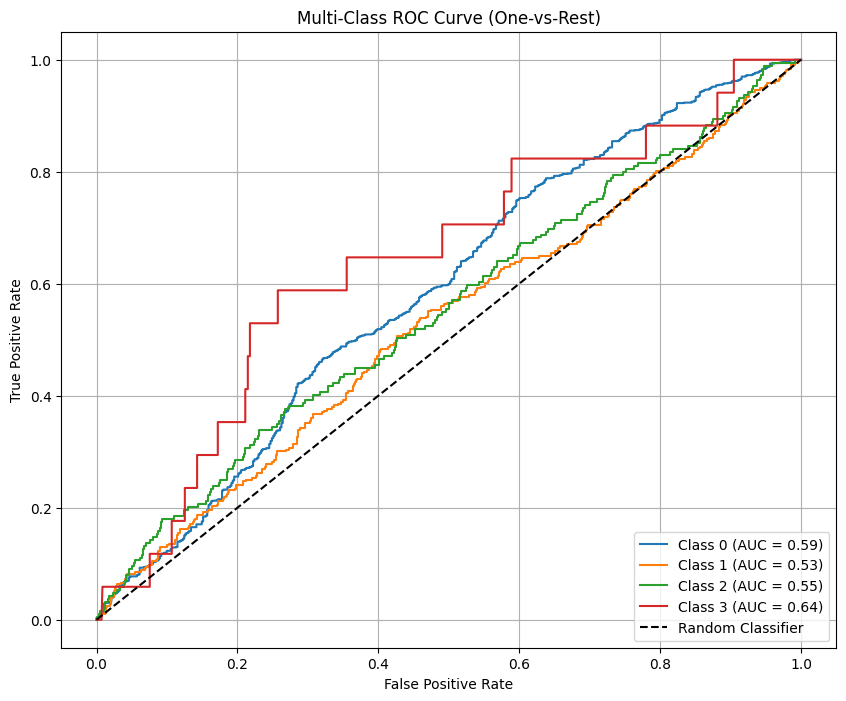

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# 1. Learning Curve del miglior modello
plt.figure(figsize=(10, 5))
plt.plot(best_mlp.loss_curve_)
plt.title("Learning Curve - Best MLP from GridSearch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.savefig('best_nn_loss_curve_replot.png')
plt.show()

# 2. Multi-Class ROC Curve (One-vs-Rest)
plt.figure(figsize=(10, 8))

# Binarize the true labels
label_binarizer = LabelBinarizer().fit(y_test)
y_test_binarized = label_binarizer.transform(y_test)

# Get predicted probabilities
y_pred_proba = best_mlp.predict_proba(X_test_scaled)

n_classes = len(label_binarizer.classes_)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {label_binarizer.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('best_nn_roc_curve.png')
plt.show()

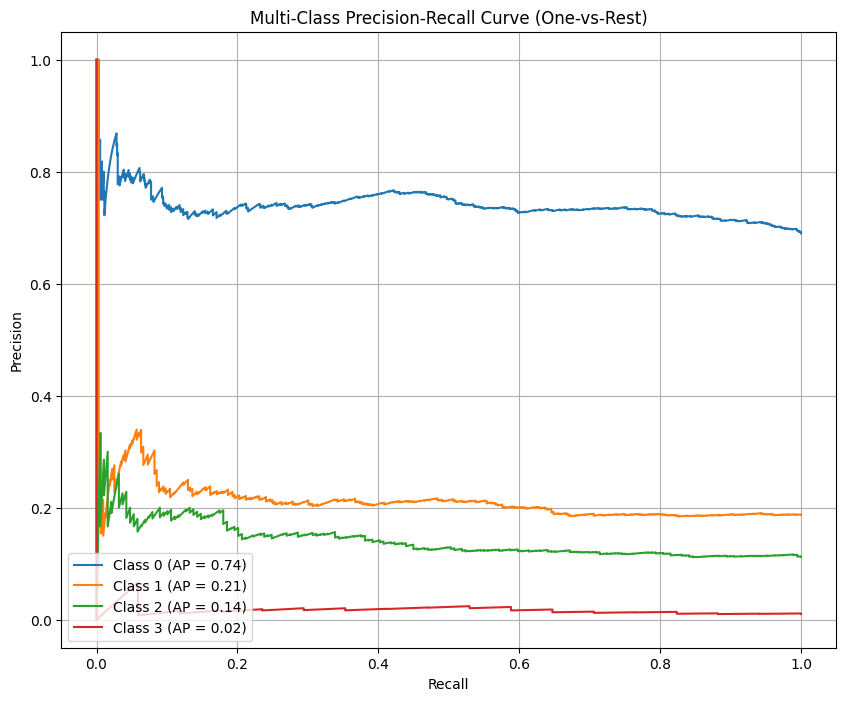

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer

# 1. Multi-Class Precision-Recall Curve (One-vs-Rest)
plt.figure(figsize=(10, 8))

# Binarize the true labels
label_binarizer = LabelBinarizer().fit(y_test)
y_test_binarized = label_binarizer.transform(y_test)

# Get predicted probabilities
y_pred_proba = best_mlp.predict_proba(X_test_scaled)

n_classes = len(label_binarizer.classes_)

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    average_precision = average_precision_score(y_test_binarized[:, i], y_pred_proba[:, i])
    plt.plot(recall, precision, label=f'Class {label_binarizer.classes_[i]} (AP = {average_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multi-Class Precision-Recall Curve (One-vs-Rest)')
plt.legend(loc='lower left')
plt.grid(True)
plt.savefig('best_nn_precision_recall_curve.png')
plt.show()

#RANDOMIZEsearch

'solver': 'sgd', 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (512, 128, 64), 'batch_size': 32, 'alpha': 0.05, 'activation': 'relu'

[14:39:20] Caricamento dataset...
[14:39:20] Preprocessing e Imputazione...
[14:39:20] Inizio bilanciamento classi (Oversampling)...


Progressivo Bilanciamento: 100%|██████████| 4/4 [00:00<00:00, 77.86it/s]

[14:39:20] Scaling dei dati...


[14:39:20] Inizio Randomized Search (90 fits totali)...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[17:04:38] Addestramento completato in 145.29 minuti.

MIGLIORI PARAMETRI:
{'solver': 'sgd', 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (512, 128, 64), 'batch_size': 32, 'alpha': 0.05, 'activation': 'relu'}

Report Classificazione (Test Set):
              precision    recall  f1-score   support

           0       0.74      0.69      0.72      1162
           1       0.22      0.28      0.24       316
           2       0.14      0.13      0.14       189
           3       0.07      0.12      0.09        17

    accuracy                           0.54      1684
   macro avg       0.29      0.30      0.30      1684
weighted avg       0.57      0.54      0.56      1684



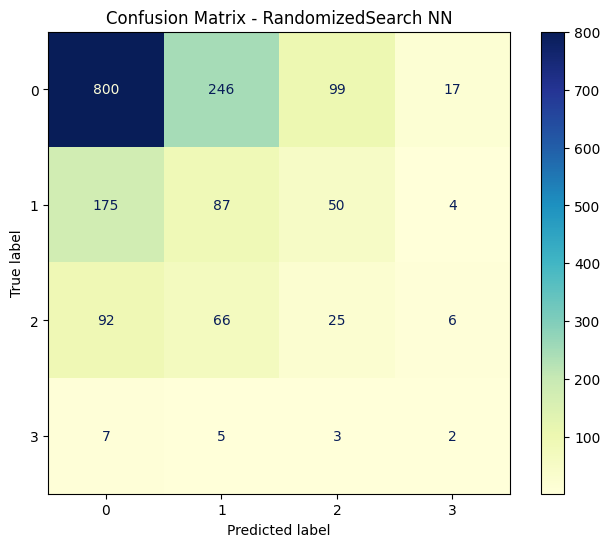

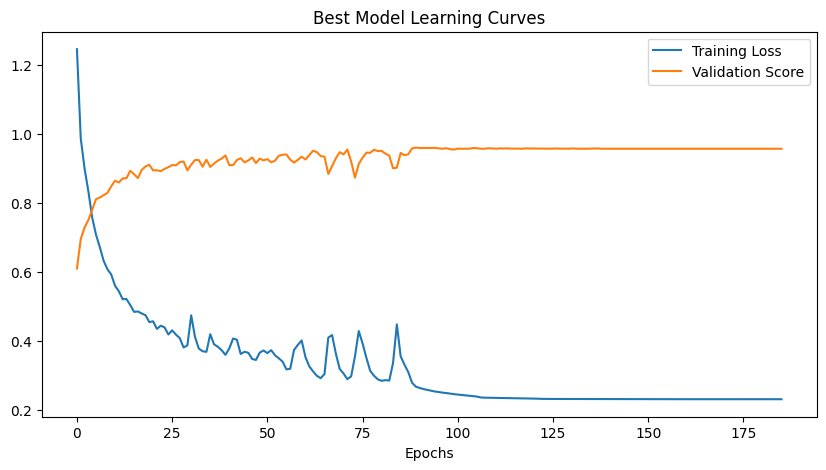

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.utils import resample
# --- AGGIUNTE PER IL TEMPO ---
from tqdm import tqdm
from datetime import datetime
import time

def log_step(message):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {message}")

# 1. CARICAMENTO E PULIZIA
log_step("Caricamento dataset...")
df = pd.read_csv('cmi_module1_clean-1.csv')

y = df['sii'].astype(int)

# 2. Esclusione colonne inutili o "leakage"
cols_to_drop = ['BIA_measured', 'SDS_measured', 'sii', 'Physical-Weight', 'Physical-Height']
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# Preprocessing: Imputazione e One-Hot Encoding
log_step("Preprocessing e Imputazione...")
X = X.fillna(X.median())
categorical_cols = [
    'BIA-BIA_Activity_Level_num', 'BIA-BIA_Frame_num',
    'ScreenTime_Category', 'PreInt_EduHx-computerinternet_hoursday'
]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 2. SPLIT TRAIN/TEST
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. BILANCIAMENTO CON BARRA DI AVANZAMENTO (tqdm)
log_step("Inizio bilanciamento classi (Oversampling)...")
train_temp = pd.concat([X_train_full, y_train_full], axis=1)
df_balanced = pd.DataFrame()
target_size = len(train_temp[train_temp.sii == 0])

# tqdm avvolge la lista delle classi per mostrare la barra
for label in tqdm([0, 1, 2, 3], desc="Progressivo Bilanciamento"):
    class_subset = train_temp[train_temp.sii == label]
    resampled_subset = resample(class_subset, replace=True, n_samples=target_size, random_state=42)
    df_balanced = pd.concat([df_balanced, resampled_subset])

X_train_res = df_balanced.drop('sii', axis=1)
y_train_res = df_balanced['sii']

# 4. SCALING
log_step("Scaling dei dati...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# 5. PARAMETRI PER RANDOMIZED SEARCH
param_dist = {
    'hidden_layer_sizes': [(256, 128, 64), (512, 128, 64), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01, 0.05],
    'learning_rate_init': [0.0001, 0.001, 0.01],
    'batch_size': [32, 64, 128],
    'learning_rate': ['adaptive']
}

mlp = MLPClassifier(
    max_iter=400,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42,
    shuffle=True
)

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# --- VERBOSE=2 PER MONITORARE I 90 FITS ---
random_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist,
    n_iter=30,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2,  # Aumentato a 2 per vedere i progressi di ogni prova
    random_state=42
)

# 6. ESECUZIONE CON TIMING FINALE
log_step("Inizio Randomized Search (90 fits totali)...")
start_time = time.time()

random_search.fit(X_train_scaled, y_train_res)

end_time = time.time()
durata = (end_time - start_time) / 60
log_step(f"Addestramento completato in {durata:.2f} minuti.")

# 7. RISULTATI FINALI
print("\n" + "="*40)
print(f"MIGLIORI PARAMETRI:\n{random_search.best_params_}")
print("="*40)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# Report e Visualizzazione
print("\nReport Classificazione (Test Set):")
print(classification_report(y_test, y_pred))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='YlGnBu', ax=ax)
plt.title("Confusion Matrix - RandomizedSearch NN")
plt.show()

# Learning Curves
plt.figure(figsize=(10, 5))
plt.plot(best_model.loss_curve_, label='Training Loss')
if hasattr(best_model, 'validation_scores_'):
    plt.plot(best_model.validation_scores_, label='Validation Score')
plt.title("Best Model Learning Curves")
plt.xlabel("Epochs")
plt.legend()
plt.show()

ROC CURVE

[07:41:01] Caricamento dataset (mantenendo 4 classi originali)...

*** Conferma Distribuzione Target 'sii' (4 classi originali): ***
sii
0    5806
1    1578
2     947
3      86
Name: count, dtype: int64
Distribuzione normalizzata:
sii
0    68.98%
1    18.75%
2    11.25%
3     1.02%
*****************************************************************
[07:41:01] Preprocessing e Imputazione...
[07:41:01] Split Train/Test...
[07:41:01] Inizio bilanciamento classi (Oversampling)...
[07:41:01] Scaling dei dati...
[07:41:01] Definizione e addestramento del modello MLPClassifier con parametri specifici (SENZA MERGE)...
[07:47:13] Addestramento completato in 6.20 minuti.

PARAMETRI DEL MODELLO:
{'solver': 'sgd', 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (512, 128, 64), 'batch_size': 32, 'alpha': 0.05, 'activation': 'relu'}

Report Classificazione (Test Set):
              precision    recall  f1-score   support

           0       0.74      0.69      0.72      

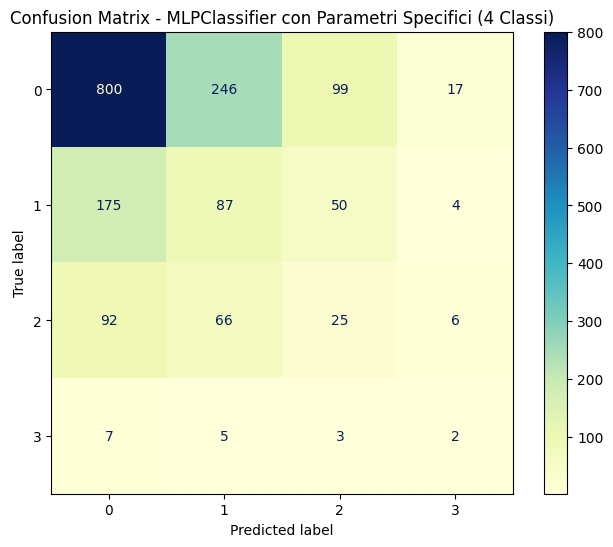

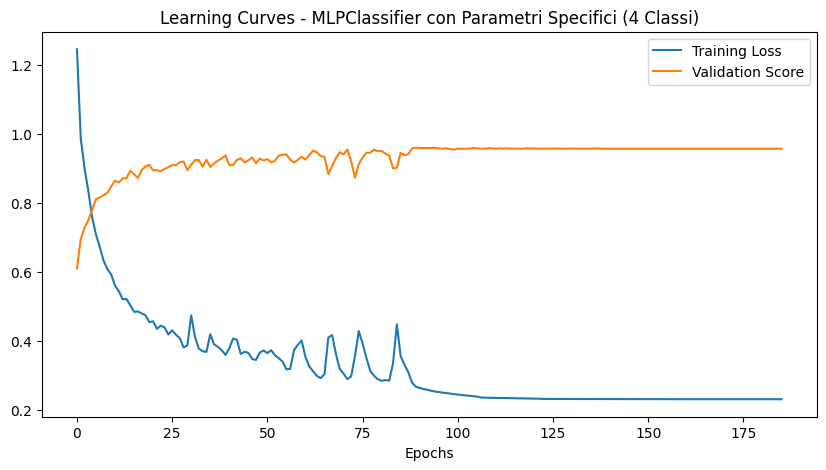

[07:47:13] Generazione della Multi-Class ROC Curve (4 Classi)...


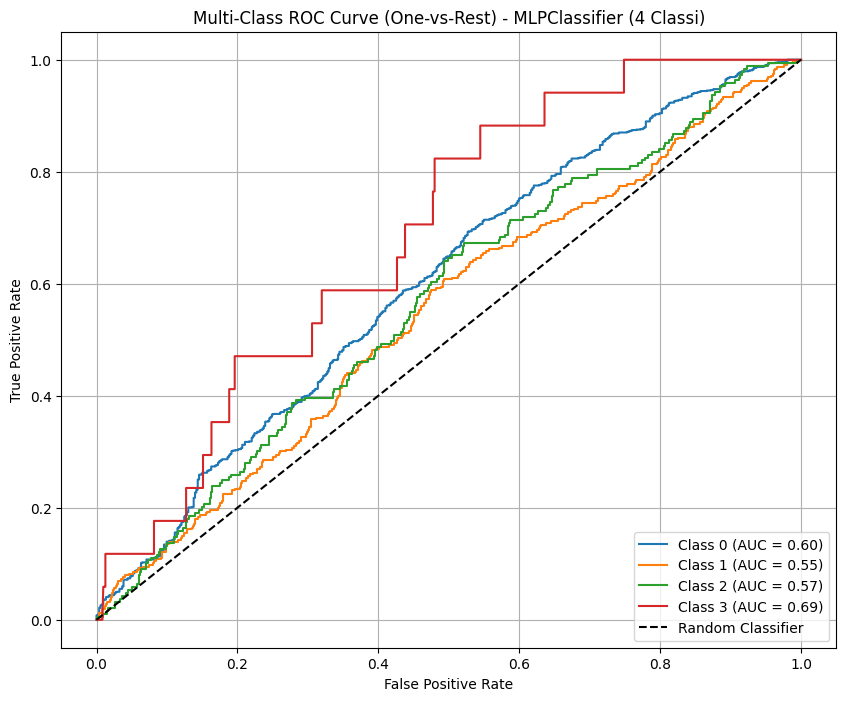

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.utils import resample
from datetime import datetime
import time

def log_step(message):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {message}")

# 1. CARICAMENTO E PULIZIA (SENZA fusione classi 2 e 3)
log_step("Caricamento dataset (mantenendo 4 classi originali)...")
df = pd.read_csv('cmi_module1_clean-1.csv')

y = df['sii'].astype(int) # Mantiene le classi 0, 1, 2, 3

# *** CONFERMA ESPLICITA DELLA DISTRIBUZIONE DEL TARGET 'sii' ***
print("\n*** Conferma Distribuzione Target 'sii' (4 classi originali): ***")
print(y.value_counts())
print("Distribuzione normalizzata:\n" + (y.value_counts(normalize=True).mul(100).round(2).astype(str) + '%').to_string())
print("*****************************************************************")

# 2. Esclusione colonne inutili o "leakage"
cols_to_drop = ['BIA_measured', 'SDS_measured', 'sii', 'Physical-Weight', 'Physical-Height']
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# Preprocessing: Imputazione e One-Hot Encoding
log_step("Preprocessing e Imputazione...")
X = X.fillna(X.median())
categorical_cols = [
    'BIA-BIA_Activity_Level_num', 'BIA-BIA_Frame_num',
    'ScreenTime_Category', 'PreInt_EduHx-computerinternet_hoursday'
]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 3. SPLIT TRAIN/TEST
log_step("Split Train/Test...")
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. BILANCIAMENTO CON OVERSAMPLING
log_step("Inizio bilanciamento classi (Oversampling)...")
train_temp = pd.concat([X_train_full, y_train_full], axis=1)
df_balanced = pd.DataFrame()
target_size = len(train_temp[train_temp.sii == 0])

for label in [0, 1, 2, 3]: # Ora iteriamo su tutte e 4 le classi originali
    class_subset = train_temp[train_temp.sii == label]
    resampled_subset = resample(class_subset, replace=True, n_samples=target_size, random_state=42)
    df_balanced = pd.concat([df_balanced, resampled_subset])

X_train_res = df_balanced.drop('sii', axis=1)
y_train_res = df_balanced['sii']

# 5. SCALING
log_step("Scaling dei dati...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


log_step("Definizione e addestramento del modello MLPClassifier con parametri specifici (SENZA MERGE)...")

# Parametri specifici forniti dall'utente
specific_params = {
    'solver': 'sgd',
    'learning_rate_init': 0.01,
    'learning_rate': 'adaptive',
    'hidden_layer_sizes': (512, 128, 64),
    'batch_size': 32,
    'alpha': 0.05,
    'activation': 'relu'
}

mlp_model = MLPClassifier(
    max_iter=400,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42,
    shuffle=True,
    **specific_params
)

start_time = time.time()
mlp_model.fit(X_train_scaled, y_train_res)
end_time = time.time()
durata = (end_time - start_time) / 60
log_step(f"Addestramento completato in {durata:.2f} minuti.")

y_pred = mlp_model.predict(X_test_scaled)


print('\n' + '='*40)
print(f"PARAMETRI DEL MODELLO:\n{specific_params}")
print('='*40)

print("\nReport Classificazione (Test Set):")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='YlGnBu', ax=ax)
plt.title("Confusion Matrix - MLPClassifier con Parametri Specifici (4 Classi)")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(mlp_model.loss_curve_, label='Training Loss')
if hasattr(mlp_model, 'validation_scores_'):
    plt.plot(mlp_model.validation_scores_, label='Validation Score')
plt.title("Learning Curves - MLPClassifier con Parametri Specifici (4 Classi)")
plt.xlabel("Epochs")
plt.legend()
plt.show()


log_step("Generazione della Multi-Class ROC Curve (4 Classi)...")

plt.figure(figsize=(10, 8))

# Binarize the true labels
label_binarizer = LabelBinarizer().fit(y_test)
y_test_binarized = label_binarizer.transform(y_test)

# Get predicted probabilities
y_pred_proba = mlp_model.predict_proba(X_test_scaled)

n_classes = len(label_binarizer.classes_)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {label_binarizer.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (One-vs-Rest) - MLPClassifier (4 Classi)')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('specific_mlp_roc_curve_4_classes.png')
plt.show()

**Loss on the Training Set:**
This curve should generally decrease as the number of epochs increases. It indicates how well the model is learning to map inputs to outputs on data it has already seen. A steady decline is good.
Loss on the Validation Set (or Validation Score):

**Validation score nel validation set:**
It indicates how well the model generalizes to previously unseen data. It should also decrease initially.

Common Interpretations:

**Underfitting:** If both curves (training and validation) are high and flat, or decrease slowly and then stabilize at a high value, the model is not learning well enough. It could be too simple (low capacity), or you need to train it for more epochs, or it may have suboptimal hyperparameters.
**Overfitting: **If the training set loss continues to decrease while the validation set loss stops decreasing or begins to increase, the model is "memorizing" the training data instead of learning generalizable patterns. This is a sign of overfitting. The model is too complex for the data, or you trained for too many epochs.
**Good Fit:** Ideally, both curves decrease and stabilize at a low value close to each other. This means the model is learning well and generalizing effectively.

#RANDOMIZE + MERGE

'solver': 'sgd', 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (512, 128, 64), 'batch_size': 32, 'alpha': 0.05, 'activation': 'relu'

Distribuzione della colonna 'sii':
sii
0.0    5806
1.0    1578
2.0     947
3.0      86
Name: count, dtype: int64

Distribuzione normalizzata della colonna 'sii':
sii
0.0    68.98%
1.0    18.75%
2.0    11.25%
3.0     1.02%
Name: proportion, dtype: object


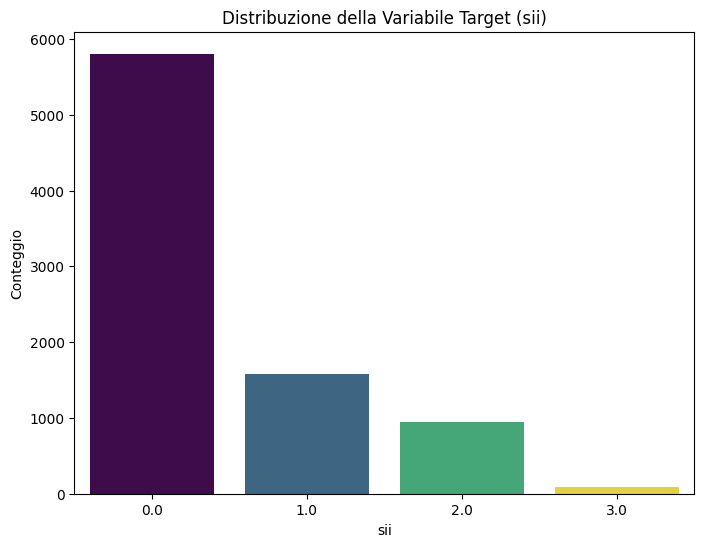

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento del dataset
df = pd.read_csv('cmi_module1_clean-1.csv')

# Verifica della distribuzione della colonna 'sii'
print("Distribuzione della colonna 'sii':")
print(df['sii'].value_counts())
print("\nDistribuzione normalizzata della colonna 'sii':")
print(df['sii'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Visualizzazione della distribuzione
plt.figure(figsize=(8, 6))
# Risoluzione del FutureWarning: assegnare 'x' a 'hue' e impostare legend=False
sns.countplot(x='sii', hue='sii', data=df, palette='viridis', legend=False)
plt.title('Distribuzione della Variabile Target (sii)')
plt.xlabel('sii')
plt.ylabel('Conteggio')
plt.show()

Distribuzione della colonna 'sii' dopo l'unione di Classe 2 e 3:
sii
0.0    5806
1.0    1578
2.0    1033
Name: count, dtype: int64

Distribuzione normalizzata della colonna 'sii' dopo l'unione:
sii
0.0    68.98%
1.0    18.75%
2.0    12.27%
Name: proportion, dtype: object


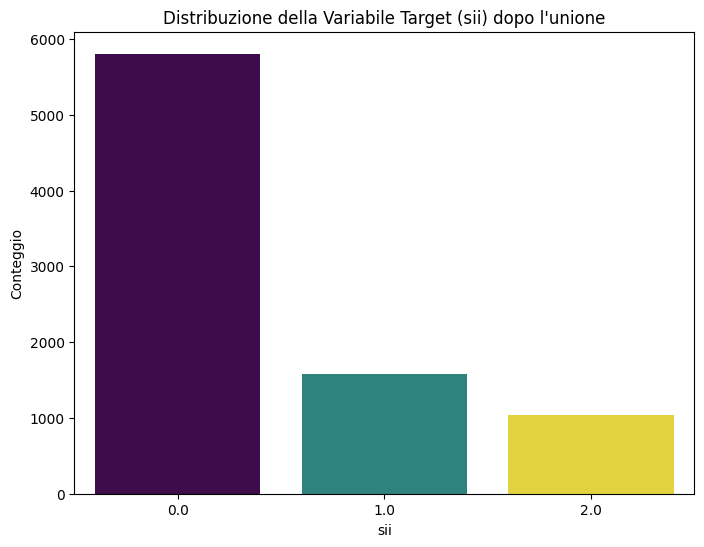

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento del dataset (se non già caricato in precedenza)
# df = pd.read_csv('cmi_module1_clean-1.csv')

# Unione delle classi 2 e 3 nella colonna 'sii'
# Sostituiamo i valori 3 con 2.0. Assicuriamoci che 'sii' sia numerico.
df['sii'] = df['sii'].replace(3.0, 2.0)

# Verifica della nuova distribuzione della colonna 'sii'
print("Distribuzione della colonna 'sii' dopo l'unione di Classe 2 e 3:")
print(df['sii'].value_counts())
print("\nDistribuzione normalizzata della colonna 'sii' dopo l'unione:")
print(df['sii'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Visualizzazione della nuova distribuzione
plt.figure(figsize=(8, 6))
sns.countplot(x='sii', hue='sii', data=df, palette='viridis', legend=False)
plt.title("Distribuzione della Variabile Target (sii) dopo l'unione")
plt.xlabel('sii')
plt.ylabel('Conteggio')
plt.show()

[13:03:16] Utilizzo del DataFrame 'df' esistente con classi 'sii' già fuse.

*** Conferma Distribuzione Target 'sii' (classi 2 e 3 fuse): ***
sii
0    5806
1    1578
2    1033
Name: count, dtype: int64
Distribuzione normalizzata:
sii
0    68.98%
1    18.75%
2    12.27%
*****************************************************************
[13:03:16] Preprocessing e Imputazione...
[13:03:16] Inizio bilanciamento classi (Oversampling)...


Progressivo Bilanciamento (Classi 0,1,2): 100%|██████████| 3/3 [00:00<00:00, 66.04it/s]

[13:03:16] Scaling dei dati...


[13:03:16] Inizio Randomized Search (90 fits totali) con classi unite...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[14:58:32] Addestramento completato in 115.26 minuti.

MIGLIORI PARAMETRI:
{'solver': 'sgd', 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (512, 128, 64), 'batch_size': 32, 'alpha': 0.05, 'activation': 'relu'}

Report Classificazione (Test Set):
              precision    recall  f1-score   support

           0       0.75      0.75      0.75      1161
           1       0.24      0.26      0.25       316
           2       0.26      0.24      0.25       207

    accuracy                           0.59      1684
   macro avg       0.42      0.42      0.42      1684
weighted avg       0.60      0.59      0.60      1684



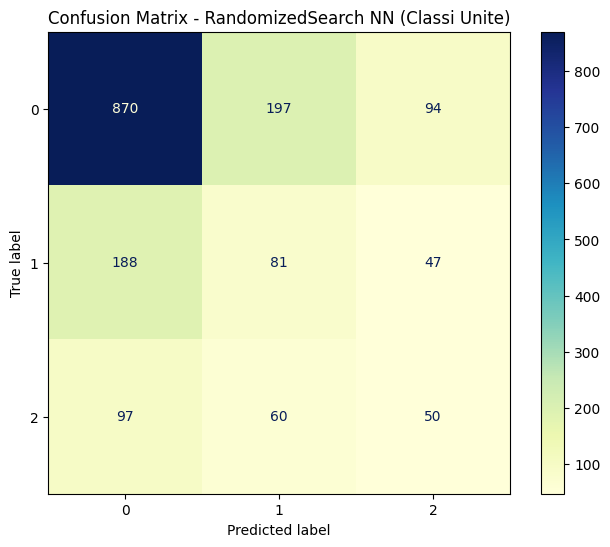

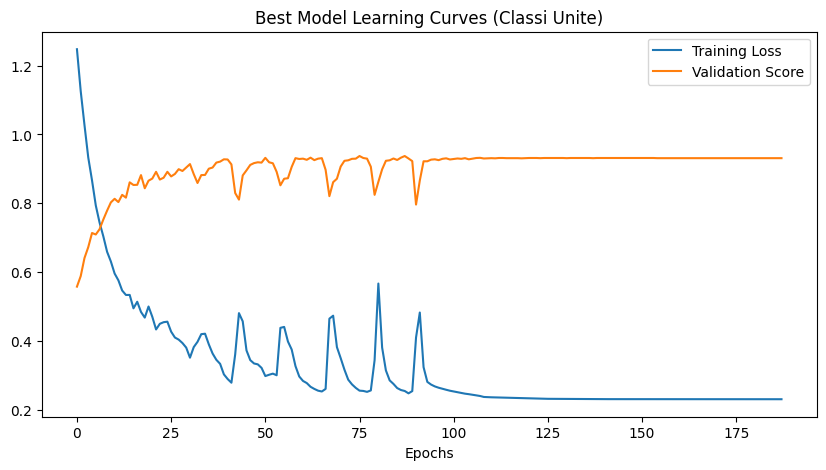

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.utils import resample
# --- AGGIUNTE PER IL TEMPO ---
from tqdm import tqdm
from datetime import datetime
import time

def log_step(message):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {message}")

# 1. CARICAMENTO E PULIZIA
log_step("Utilizzo del DataFrame 'df' esistente con classi 'sii' già fuse.")
# df è già stato caricato e le classi 2 e 3 sono state fuse nella cella precedente (H3v5HCVPTpAf).
# Non ricarichiamo e non rifacciamo la fusione qui per coerenza.

y = df['sii'].astype(int)

# *** CONFERMA ESPLICITA DELLA DISTRIBUZIONE DEL TARGET 'sii' ***
print("\n*** Conferma Distribuzione Target 'sii' (classi 2 e 3 fuse): ***")
print(y.value_counts())
print("Distribuzione normalizzata:\n" + (y.value_counts(normalize=True).mul(100).round(2).astype(str) + '%').to_string())
print("*****************************************************************")

# 2. Esclusione colonne inutili o "leakage"
cols_to_drop = ['BIA_measured', 'SDS_measured', 'sii', 'Physical-Weight', 'Physical-Height']
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# Preprocessing: Imputazione e One-Hot Encoding
log_step("Preprocessing e Imputazione...")
X = X.fillna(X.median())
categorical_cols = [
    'BIA-BIA_Activity_Level_num', 'BIA-BIA_Frame_num',
    'ScreenTime_Category', 'PreInt_EduHx-computerinternet_hoursday'
]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 2. SPLIT TRAIN/TEST
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. BILANCIAMENTO CON BARRA DI AVANZAMENTO (tqdm)
log_step("Inizio bilanciamento classi (Oversampling)...")
train_temp = pd.concat([X_train_full, y_train_full], axis=1)
df_balanced = pd.DataFrame()
target_size = len(train_temp[train_temp.sii == 0])

# tqdm avvolge la lista delle classi per mostrare la barra
# Ora abbiamo solo 3 classi: 0, 1, 2 (dopo la fusione)
for label in tqdm([0, 1, 2], desc="Progressivo Bilanciamento (Classi 0,1,2)"):
    class_subset = train_temp[train_temp.sii == label]
    resampled_subset = resample(class_subset, replace=True, n_samples=target_size, random_state=42)
    df_balanced = pd.concat([df_balanced, resampled_subset])

X_train_res = df_balanced.drop('sii', axis=1)
y_train_res = df_balanced['sii']

# 4. SCALING
log_step("Scaling dei dati...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# 5. PARAMETRI PER RANDOMIZED SEARCH
param_dist = {
    'hidden_layer_sizes': [(256, 128, 64), (512, 128, 64), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01, 0.05],
    'learning_rate_init': [0.0001, 0.001, 0.01],
    'batch_size': [32, 64, 128],
    'learning_rate': ['adaptive']
}

mlp = MLPClassifier(
    max_iter=400,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42,
    shuffle=True
)

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# --- VERBOSE=2 PER MONITORARE I 90 FITS ---
random_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist,
    n_iter=30,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2,  # Aumentato a 2 per vedere i progressi di ogni prova
    random_state=42
)

# 6. ESECUZIONE CON TIMING FINALE
log_step("Inizio Randomized Search (90 fits totali) con classi unite...")
start_time = time.time()

random_search.fit(X_train_scaled, y_train_res)

end_time = time.time()
durata = (end_time - start_time) / 60
log_step(f"Addestramento completato in {durata:.2f} minuti.")

# 7. RISULTATI FINALI
print("\n" + "="*40)
print(f"MIGLIORI PARAMETRI:\n{random_search.best_params_}")
print("="*40)

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# Report e Visualizzazione
print("\nReport Classificazione (Test Set):")
print(classification_report(y_test, y_pred))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='YlGnBu', ax=ax)
plt.title("Confusion Matrix - RandomizedSearch NN (Classi Unite)")
plt.show()

# Learning Curves
plt.figure(figsize=(10, 5))
plt.plot(best_model.loss_curve_, label='Training Loss')
if hasattr(best_model, 'validation_scores_'):
    plt.plot(best_model.validation_scores_, label='Validation Score')
plt.title("Best Model Learning Curves (Classi Unite)")
plt.xlabel("Epochs")
plt.legend()
plt.show()

ROC CURVE

[08:23:39] Caricamento dataset e fusione classi...

*** Conferma Distribuzione Target 'sii' (classi 2 e 3 fuse): ***
sii
0    5806
1    1578
2    1033
Name: count, dtype: int64
Distribuzione normalizzata:
sii
0    68.98%
1    18.75%
2    12.27%
*****************************************************************
[08:23:39] Preprocessing e Imputazione...
[08:23:39] Split Train/Test...
[08:23:39] Inizio bilanciamento classi (Oversampling)...
[08:23:39] Scaling dei dati...
[08:23:39] Definizione e addestramento del modello MLPClassifier con parametri specifici (CON MERGE)...
[08:28:01] Addestramento completato in 4.35 minuti.

PARAMETRI DEL MODELLO:
{'solver': 'sgd', 'learning_rate_init': 0.01, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (512, 128, 64), 'batch_size': 32, 'alpha': 0.05, 'activation': 'relu'}

Report Classificazione (Test Set):
              precision    recall  f1-score   support

           0       0.75      0.75      0.75      1161
           1       0.24      0.26  

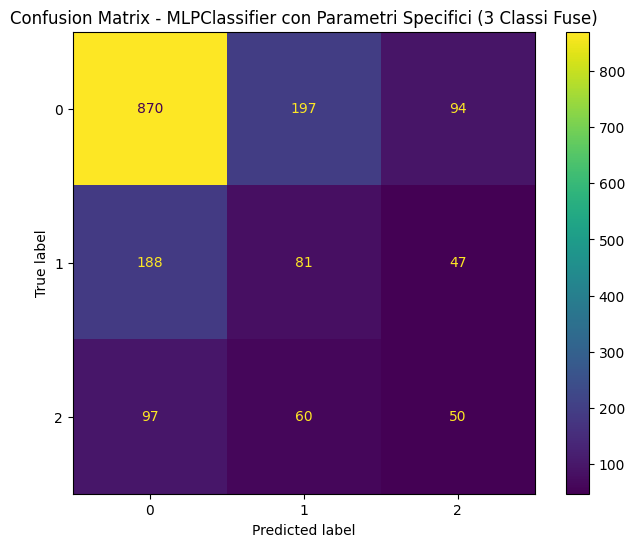

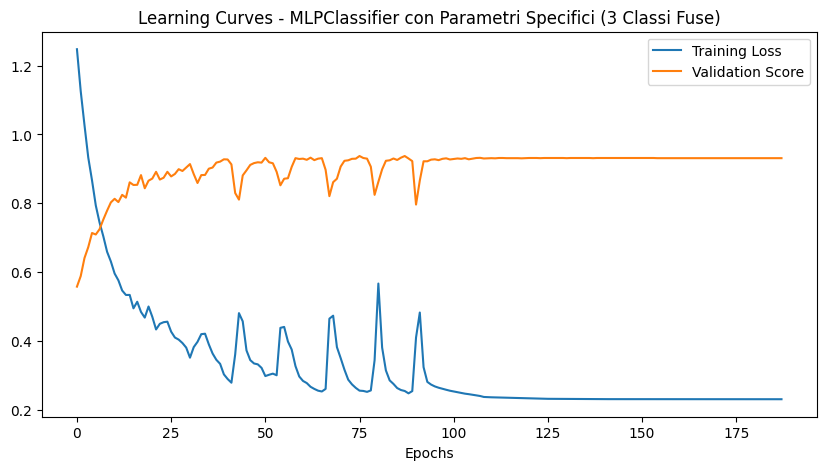

[08:28:01] Generazione della Multi-Class ROC Curve (3 Classi Fuse)...


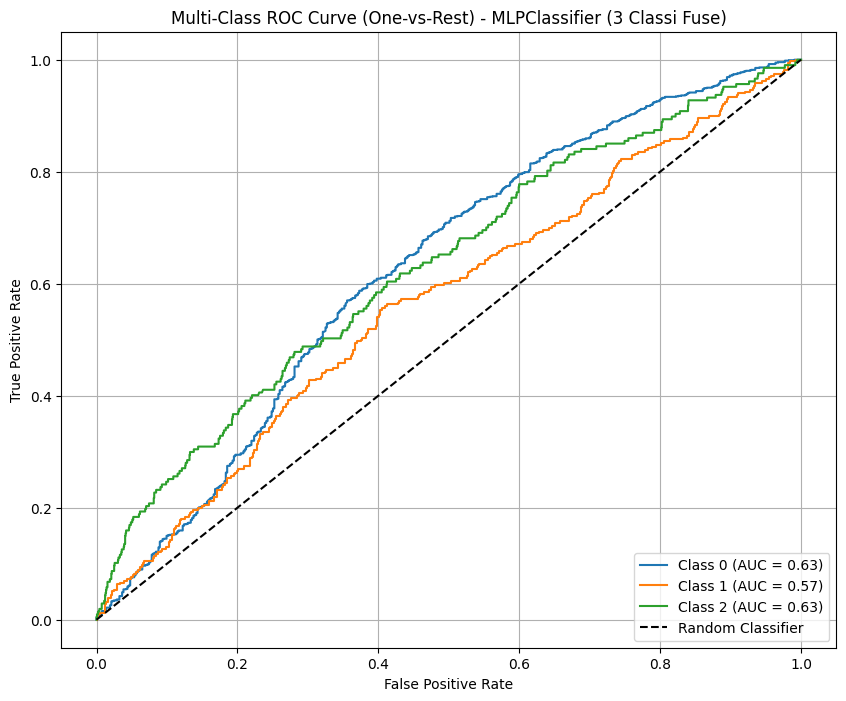

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.utils import resample
from datetime import datetime
import time

def log_step(message):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {message}")

# 1. CARICAMENTO E PULIZIA (con fusione classi)
log_step("Caricamento dataset e fusione classi...")
df = pd.read_csv('cmi_module1_clean-1.csv')
df['sii'] = df['sii'].replace(3.0, 2.0) # Fusione classi 3 in 2

y = df['sii'].astype(int)

# *** CONFERMA ESPLICITA DELLA DISTRIBUZIONE DEL TARGET 'sii' ***
print("\n*** Conferma Distribuzione Target 'sii' (classi 2 e 3 fuse): ***")
print(y.value_counts())
print("Distribuzione normalizzata:\n" + (y.value_counts(normalize=True).mul(100).round(2).astype(str) + '%').to_string())
print("*****************************************************************")

# 2. Esclusione colonne inutili o "leakage"
cols_to_drop = ['BIA_measured', 'SDS_measured', 'sii', 'Physical-Weight', 'Physical-Height']
X = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# Preprocessing: Imputazione e One-Hot Encoding
log_step("Preprocessing e Imputazione...")
X = X.fillna(X.median())
categorical_cols = [
    'BIA-BIA_Activity_Level_num', 'BIA-BIA_Frame_num',
    'ScreenTime_Category', 'PreInt_EduHx-computerinternet_hoursday'
]
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 3. SPLIT TRAIN/TEST
log_step("Split Train/Test...")
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. BILANCIAMENTO CON OVERSAMPLING
log_step("Inizio bilanciamento classi (Oversampling)...")
train_temp = pd.concat([X_train_full, y_train_full], axis=1)
df_balanced = pd.DataFrame()
target_size = len(train_temp[train_temp.sii == 0])

for label in [0, 1, 2]: # Ora abbiamo solo 3 classi: 0, 1, 2
    class_subset = train_temp[train_temp.sii == label]
    resampled_subset = resample(class_subset, replace=True, n_samples=target_size, random_state=42)
    df_balanced = pd.concat([df_balanced, resampled_subset])

X_train_res = df_balanced.drop('sii', axis=1)
y_train_res = df_balanced['sii']

# 5. SCALING
log_step("Scaling dei dati...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


log_step("Definizione e addestramento del modello MLPClassifier con parametri specifici (CON MERGE)...")

# Parametri specifici forniti dall'utente
specific_params = {
    'solver': 'sgd',
    'learning_rate_init': 0.01,
    'learning_rate': 'adaptive',
    'hidden_layer_sizes': (512, 128, 64),
    'batch_size': 32,
    'alpha': 0.05,
    'activation': 'relu'
}

mlp_model = MLPClassifier(
    max_iter=400,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42,
    shuffle=True,
    **specific_params
)

start_time = time.time()
mlp_model.fit(X_train_scaled, y_train_res)
end_time = time.time()
durata = (end_time - start_time) / 60
log_step(f"Addestramento completato in {durata:.2f} minuti.")

y_pred = mlp_model.predict(X_test_scaled)


print('\n' + '='*40)
print(f"PARAMETRI DEL MODELLO:\n{specific_params}")
print('='*40)

print("\nReport Classificazione (Test Set):")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='viridis', ax=ax)
plt.title("Confusion Matrix - MLPClassifier con Parametri Specifici (3 Classi Fuse)")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(mlp_model.loss_curve_, label='Training Loss')
if hasattr(mlp_model, 'validation_scores_'):
    plt.plot(mlp_model.validation_scores_, label='Validation Score')
plt.title("Learning Curves - MLPClassifier con Parametri Specifici (3 Classi Fuse)")
plt.xlabel("Epochs")
plt.legend()
plt.show()


log_step("Generazione della Multi-Class ROC Curve (3 Classi Fuse)...")

plt.figure(figsize=(10, 8))

# Binarize the true labels
label_binarizer = LabelBinarizer().fit(y_test)
y_test_binarized = label_binarizer.transform(y_test)

# Get predicted probabilities
y_pred_proba = mlp_model.predict_proba(X_test_scaled)

n_classes = len(label_binarizer.classes_)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {label_binarizer.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (One-vs-Rest) - MLPClassifier (3 Classi Fuse)')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('specific_mlp_roc_curve_3_classes_merged.png')
plt.show()

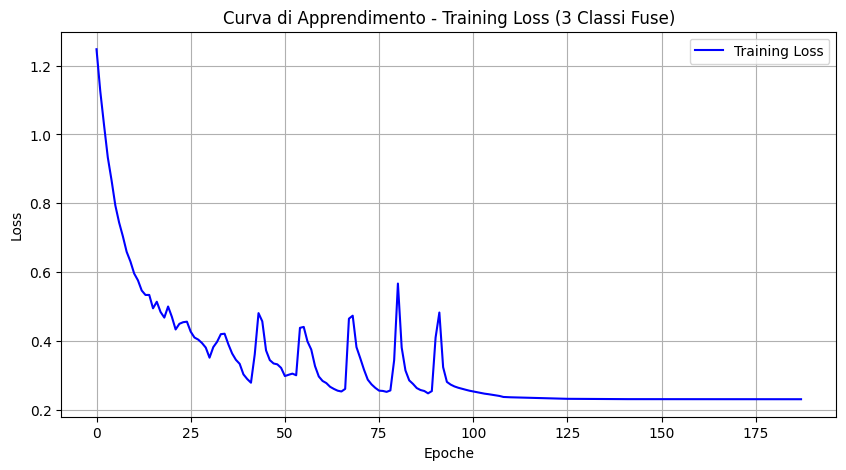

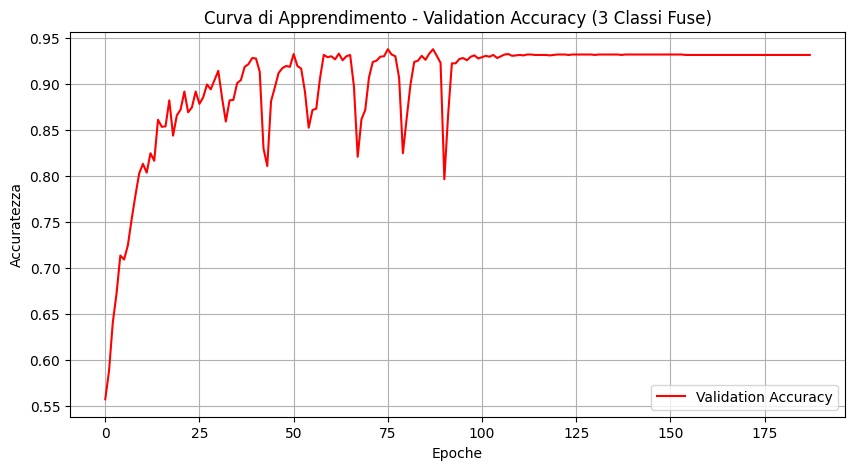

In [ ]:
import matplotlib.pyplot as plt

# Verifica se il modello è stato addestrato e ha gli attributi necessari
if 'mlp_model' in locals() and hasattr(mlp_model, 'loss_curve_') and hasattr(mlp_model, 'validation_scores_'):
    # Plot della Training Loss
    plt.figure(figsize=(10, 5))
    plt.plot(mlp_model.loss_curve_, label='Training Loss', color='blue')
    plt.title("Curva di Apprendimento - Training Loss (3 Classi Fuse)")
    plt.xlabel("Epoche")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot della Validation Accuracy
    plt.figure(figsize=(10, 5))
    plt.plot(mlp_model.validation_scores_, label='Validation Accuracy', color='red')
    plt.title("Curva di Apprendimento - Validation Accuracy (3 Classi Fuse)")
    plt.xlabel("Epoche")
    plt.ylabel("Accuratezza")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Il modello MLPClassifier non è stato ancora addestrato o non contiene gli attributi 'loss_curve_' o 'validation_scores_'. Esegui prima le celle di addestramento.")


In [ ]:
function KeepAlive(){
  console.log("Mantenendo vivo il runtime...");
  document.querySelector("colab-connect-button").click()
}
setInterval(KeepAlive, 60000)